# Principal Component Analysis (PCA)

**Author:** Varun Singh

**GitHub:** https://github.com/varunsingh-dev

**Repository:** Machine Learning

**Module:** 08_PCA

**Dataset:** Wine.csv

**Objective:** Reduce the dimensionality of the Wine dataset while preserving important information using PCA.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##  Load Dataset

In [48]:
df=pd.read_csv("/content/wine.csv")
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


##  Dataset Shape

In [49]:
df.shape

(178, 14)

##  Dataset Columns

In [50]:
df.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

##  Dataset Information

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


##  Statistical Summary

In [52]:
df.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Check datatype

In [53]:
df.dtypes

,0
Wine,int64
Alcohol,float64
Malic.acid,float64
Ash,float64
Acl,float64
Mg,int64
Phenols,float64
Flavanoids,float64
Nonflavanoid.phenols,float64
Proanth,float64


##  Check Missing Values

In [54]:
df.isnull().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


##  Separate Features and Target

In [55]:
x = df.drop("Wine",axis=1)

y = df["Wine"]

print("feature Shape", x.shape)
print("Target Shape",y.shape)

feature Shape (178, 13)
Target Shape (178,)


##  Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(
    x_scaled,
    columns=x.columns
)

x_scaled.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


##  Apply Principal Component Analysis (PCA)

In [57]:
from sklearn.decomposition import PCA

pca = PCA()

x_pca = pca.fit_transform(x_scaled)

print("Origional Feature:",x.shape[1])
print("PCA Components:",x_pca.shape[1])

Origional Feature: 13
PCA Components: 13


##  Explained Variance Ratio

In [58]:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


##  Cumulative Explained Variance

In [59]:
cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


##  Explained Variance Visualization

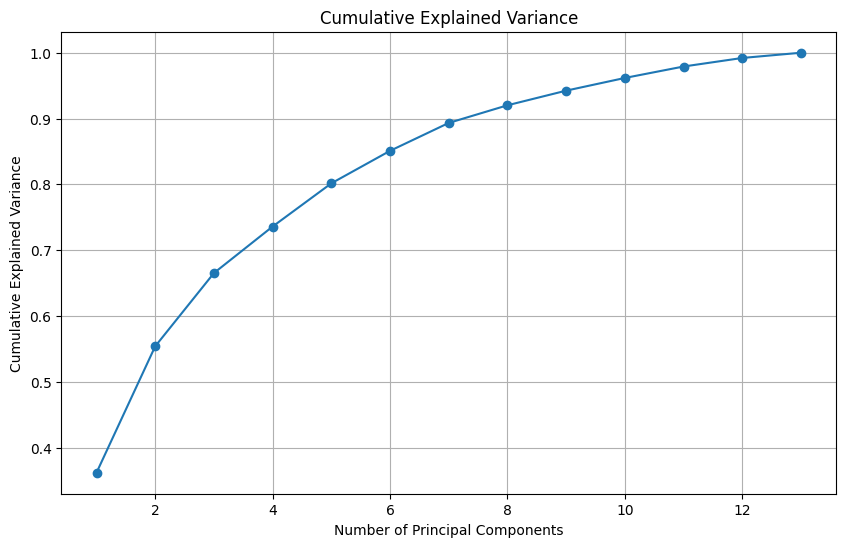

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid(True)
plt.show()

##  Select Principal Components

In [61]:
pca_2d = PCA(n_components=2)

x_pca_2d = pca_2d.fit_transform(x_scaled)

print("Original Shape:", x.shape)
print("Reduced Shape:", x_pca_2d.shape)

Original Shape: (178, 13)
Reduced Shape: (178, 2)


##  PCA Transformed Data

In [62]:
pca_df = pd.DataFrame(
    x_pca_2d,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Wine"] = y.values

pca_df.head()

,Principal Component 1,Principal Component 2,Wine
0,3.316751,1.443463,1
1,2.209465,-0.333393,1
2,2.516740,1.031151,1
3,3.757066,2.756372,1
4,1.008908,0.869831,1


##  PCA 2D Visualization

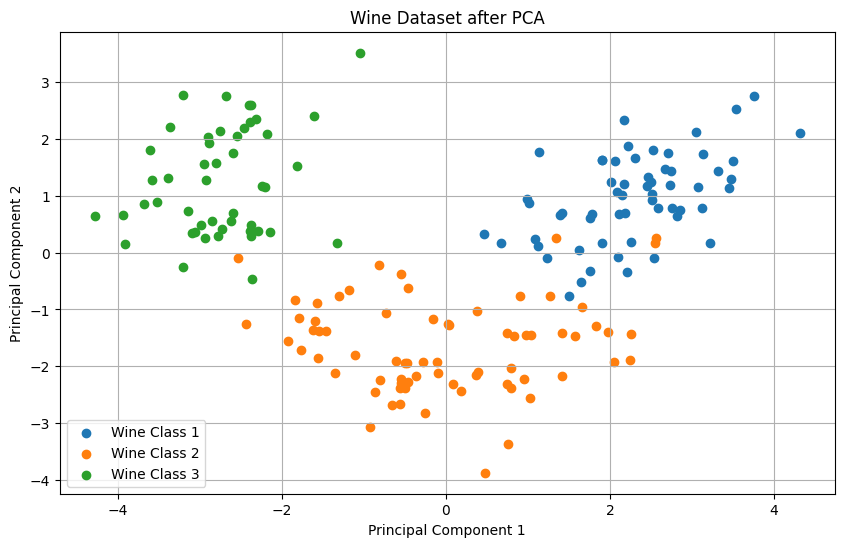

In [63]:
plt.figure(figsize=(10,6))

for wine_class in sorted(pca_df["Wine"].unique()):
  class_data = pca_df[pca_df["Wine"] == wine_class]

  plt.scatter(
      class_data["Principal Component 1"],
      class_data["Principal Component 2"],
      label=f"Wine Class {wine_class}"
  )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset after PCA")
plt.legend()
plt.grid(True)

plt.show()

##  Explained Variance of Selected Components

In [64]:
print(
    "PC1 Explained Variance:",
    pca_2d.explained_variance_ratio_[0]
)

print(
    "PC2 Explained Variance:",
    pca_2d.explained_variance_ratio_[1]
)

print(
    "Total Explained Variance:",
    pca_2d.explained_variance_ratio_.sum()
)

PC1 Explained Variance: 0.3619884809992633
PC2 Explained Variance: 0.1920749025700894
Total Explained Variance: 0.5540633835693527


##  Principal Component Loadings

In [65]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=x.columns
)

loadings

,PC1,PC2
Alcohol,0.144329,0.483652
Malic.acid,-0.245188,0.224931
Ash,-0.002051,0.316069
Acl,-0.239320,-0.010591
Mg,0.141992,0.299634
Phenols,0.394661,0.065040
Flavanoids,0.422934,-0.003360
Nonflavanoid.phenols,-0.298533,0.028779
Proanth,0.313429,0.039302
Color.int,-0.088617,0.529996


##  Final Reduced Dataset

In [66]:
pca_df.head(10)

,Principal Component 1,Principal Component 2,Wine
0,3.316751,1.443463,1
1,2.209465,-0.333393,1
2,2.516740,1.031151,1
3,3.757066,2.756372,1
4,1.008908,0.869831,1
5,3.050254,2.122401,1
6,2.449090,1.174850,1
7,2.059437,1.608963,1
8,2.510874,0.918071,1
9,2.753628,0.789438,1


##  Dimensionality Reduction Summary

The original Wine dataset contained 13 numerical features.

Using PCA, the dataset was transformed into 2 principal components for visualization.

This reduced the dimensionality from 13 features to 2 components while retaining a significant portion of the original variance.

# ✅ Key Learnings

- Understood the concept of dimensionality reduction.
- Explored the Wine dataset.
- Identified features and target labels.
- Standardized the numerical features.
- Applied Principal Component Analysis.
- Analyzed explained variance.
- Reduced 13 features to 2 principal components.
- Visualized the transformed dataset.
- Analyzed principal component loadings.
- Understood how PCA can simplify high-dimensional datasets.

## 🎯 Project Summary

In this project, Principal Component Analysis (PCA) was applied to the Wine dataset to reduce its dimensionality.

The original 13 numerical features were transformed into principal components. The first two components were used to create a 2D visualization of the wine classes.

PCA demonstrated how dimensionality reduction can simplify complex datasets while retaining important information from the original features.